In [1]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import PIL 
import tensorflow as tf
import numpy as np
import os 
import matplotlib.pyplot as plt
import cv2
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

I0000 00:00:1786864363.390965    5029 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786864370.900713    5029 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786864377.969874    5029 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file("flowers_photos", origin=dataset_url, cache_dir=".", untar=True)

In [20]:
data_dir

PosixPath('datasets/flowers_photos')

In [21]:
import pathlib

In [27]:
data_dir = pathlib.Path("datasets/flowers_photos/flower_photos")
data_dir

PosixPath('datasets/flowers_photos/flower_photos')

In [28]:
print(data_dir.exists())

True


In [29]:
print(list(data_dir.iterdir()))

[PosixPath('datasets/flowers_photos/flower_photos/tulips'), PosixPath('datasets/flowers_photos/flower_photos/sunflowers'), PosixPath('datasets/flowers_photos/flower_photos/roses'), PosixPath('datasets/flowers_photos/flower_photos/dandelion'), PosixPath('datasets/flowers_photos/flower_photos/daisy'), PosixPath('datasets/flowers_photos/flower_photos/LICENSE.txt')]


In [30]:
image_count = len(list(data_dir.glob('*/*.jpg')))
image_count

3670

In [42]:
roses = list(data_dir.glob('roses/*'))
roses[:4]

[PosixPath('datasets/flowers_photos/flower_photos/roses/3292654244_4a220ab96f_m.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/5172171681_5934378f08.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/145862135_ab710de93c_n.jpg'),
 PosixPath('datasets/flowers_photos/flower_photos/roses/5156037859_1673720a11_m.jpg')]

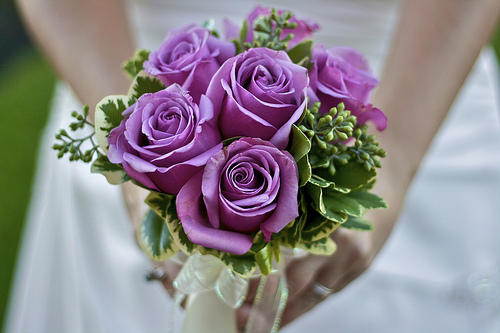

In [44]:
PIL.Image.open(str(roses[1])

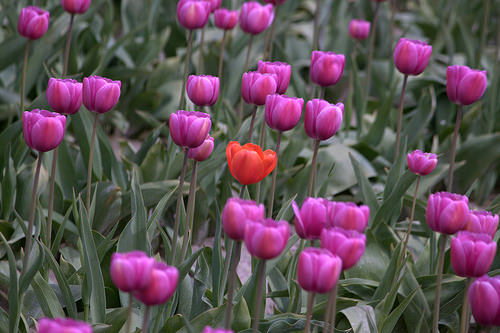

In [46]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(tulips[1])

In [48]:
flowers_image_dict = {
    "roses": list(data_dir.glob("roses/*")),
    "daisy": list(data_dir.glob("daisy/*")),
    "dandelion": list(data_dir.glob("dandelion/*")),
    "sunflowers": list(data_dir.glob("sunflowers/*")),
    "tulips": list(data_dir.glob("tulips/*"))
}

In [49]:
flowers_labels_dict = {
    "roses": 0,
    "daisy": 1,
    "dandelion": 2,
    "sunflowers": 3,
    "tulips": 4,
}

In [50]:
# lets convert every single image into numpy array with opencv